# Integrated power-flux parameter sweep

Read every power_flux_timeseries_{maximum_wind_m_s}_{radius_km}.csv file, integrate the outward power flux from 0 to time_max, and plot the result on the maximum-wind/radius parameter plane.

In [3]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np

# This works when Jupyter starts in either the repository root or plots/.
cwd = Path.cwd().resolve()
repo_root = next(
    (path for path in (cwd, *cwd.parents) if (path / "src" / "config.yaml").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

output_dir = repo_root / "outputs"
print(f"Reading model output from {output_dir}")

Reading model output from /geode3/home/u020/ckieu/BigRed200/model/vortex-waves/outputs


In [20]:
def get_flux_grid(files,time_max_s,prefix):
    number = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
    filename_pattern = re.compile(
        rf"^{prefix}_(?P<wind>{number})_(?P<radius>{number})\.csv$"
    )
    
    integrated_flux = {}
    for power_path in files:
        match = filename_pattern.fullmatch(power_path.name)
        if match is None:
            continue
    
        maximum_wind_m_s = float(match.group("wind"))
        radius_km = float(match.group("radius"))
        key = (maximum_wind_m_s, radius_km)
        if key in integrated_flux:
            raise ValueError(f"Duplicate parameter pair {key} in {power_path.name}")
    
        data = np.atleast_1d(np.genfromtxt(power_path, delimiter=",", names=True))
        column_names = set(data.dtype.names or ())
        missing_columns = {"time_s", "power_W"} - column_names
        if missing_columns:
            raise ValueError(f"{power_path.name} is missing columns {sorted(missing_columns)}")
    
        time_s = np.asarray(data["time_s"], dtype=float)
        power_w = np.asarray(data["power_W"], dtype=float)
        if time_s.size < 2 or not np.all(np.isfinite(time_s)) or not np.all(np.isfinite(power_w)):
            raise ValueError(f"{power_path.name} must contain at least two finite samples")
    
        order = np.argsort(time_s)
        time_s = time_s[order]
        power_w = power_w[order]
        if np.any(np.diff(time_s) <= 0.0):
            raise ValueError(f"{power_path.name} has duplicate or non-increasing times")
        if time_s[0] > 0.0 or time_s[-1] < time_max_s:
            raise ValueError(
                f"{power_path.name} covers {time_s[0] / 3600:g} to "
                f"{time_s[-1] / 3600:g} h, not the requested 0 to {time_max:g} h"
            )
    
        # Add interpolated endpoints so the integral ends exactly at time_max.
        interior = (time_s > 0.0) & (time_s < time_max_s)
        integration_time_s = np.concatenate(([0.0], time_s[interior], [time_max_s]))
        integration_power_w = np.interp(integration_time_s, time_s, power_w)
        integrated_flux[key] = float(np.trapezoid(integration_power_w, integration_time_s))
    
    if not integrated_flux:
        raise FileNotFoundError(
            f"No files matching power_flux_timeseries_<wind>_<radius>.csv found in {output_dir}"
        )
    
    wind_values = np.array(sorted({wind for wind, _ in integrated_flux}))
    radius_values = np.array(sorted({radius for _, radius in integrated_flux}))
    flux_grid = np.full((radius_values.size, wind_values.size), np.nan)
    wind_index = {value: index for index, value in enumerate(wind_values)}
    radius_index = {value: index for index, value in enumerate(radius_values)}
    for (wind, radius), flux in integrated_flux.items():
        flux_grid[radius_index[radius], wind_index[wind]] = flux
    
    missing_pairs = int(np.isnan(flux_grid).sum())
    if missing_pairs:
        print(f"Warning: {missing_pairs} wind/radius combinations are missing and will be blank.")
    print(
        f"Integrated {len(integrated_flux)} files from 0 to {time_max:g} h; "
        f"grid shape = {flux_grid.shape}."
    )
    
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    mesh = ax.pcolormesh(
        wind_values,
        radius_values,
        np.ma.masked_invalid(flux_grid),
        shading="nearest",
        cmap="viridis",
    )
    ax.scatter(*np.meshgrid(wind_values, radius_values), s=15, color="white", alpha=0.65)
    ax.set(
        xlabel="Maximum wind speed (m s$^{-1}$)",
        ylabel="Radius (km)",
        title=f"Integrated outward power flux, 0–{time_max:g} h",
        xticks=wind_values,
        yticks=radius_values,
    )
    colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    colorbar.set_label("Time-integrated outward power flux (J)")
    colorbar.formatter.set_powerlimits((0, 0))
    colorbar.update_ticks()
    fig.tight_layout()
    plt.show()    

    return integrated_flux

## 1. Plot at far-field location r = 1350 km

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


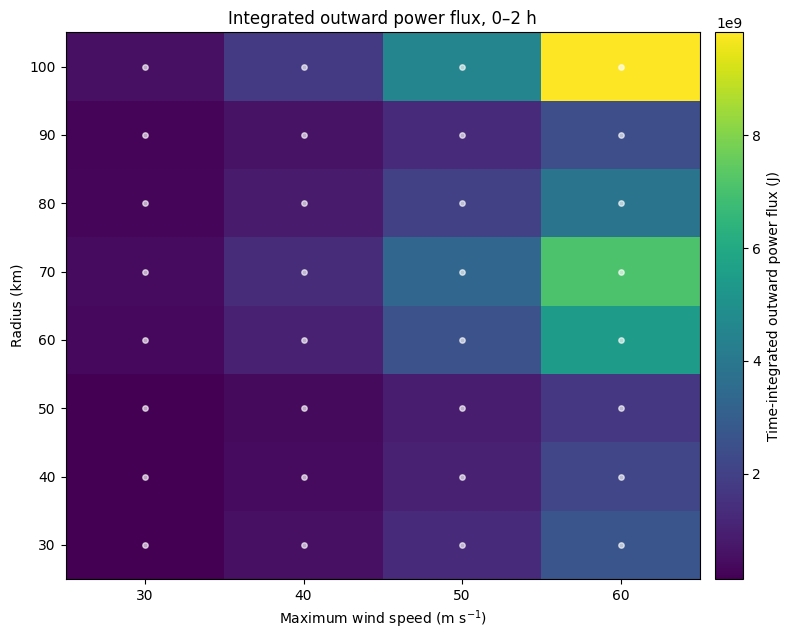

In [17]:
# Integration limit in hours. Change this value as needed.
time_max = 2.0
time_max_s = time_max * 3600.0
if time_max <= 0.0:
    raise ValueError("time_max must be greater than zero.")

prefix = "power_flux_timeseries"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_far_field = get_flux_grid(files,time_max_s)

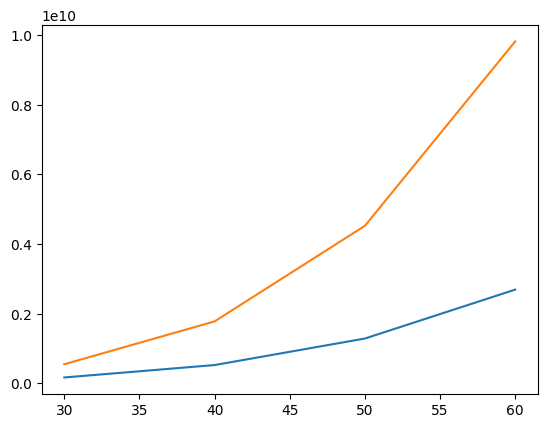

In [15]:
# the best fitting in the above graph is ~ 10.3 R^3.92 R^0.882 
wind_values = np.array(sorted({wind for wind, _ in flux_far_field}))
radius_values = np.array(sorted({radius for _, radius in flux_far_field}))
flux_grid = np.full((radius_values.size, wind_values.size), np.nan)
wind_index = {value: index for index, value in enumerate(wind_values)}
radius_index = {value: index for index, value in enumerate(radius_values)}

for (wind, radius), flux in flux_far_field.items():
    flux_grid[radius_index[radius], wind_index[wind]] = flux
plt.plot(wind_values,flux_grid[0,:])
plt.plot(wind_values,flux_grid[7,:])

## 2. Plot near the RMW at R = 180 km

Integrated 32 files from 0 to 2 h; grid shape = (8, 4).


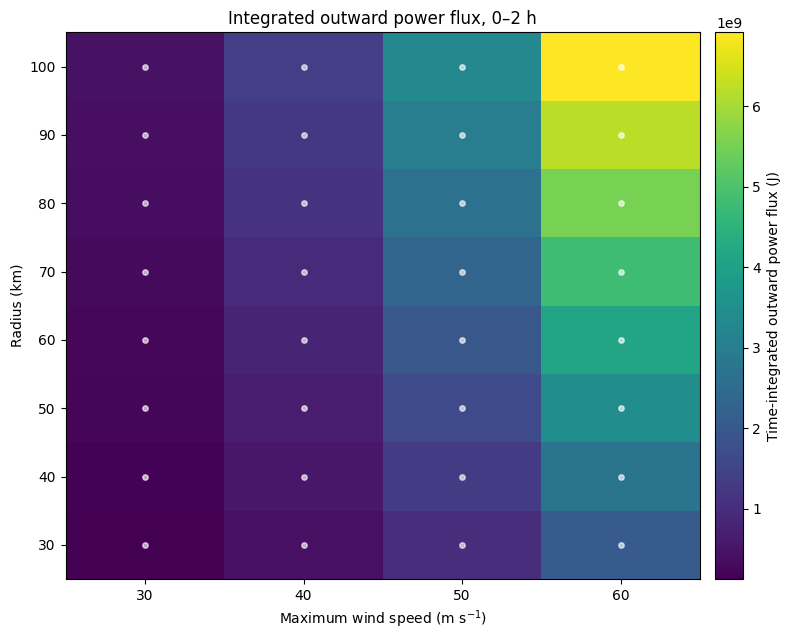

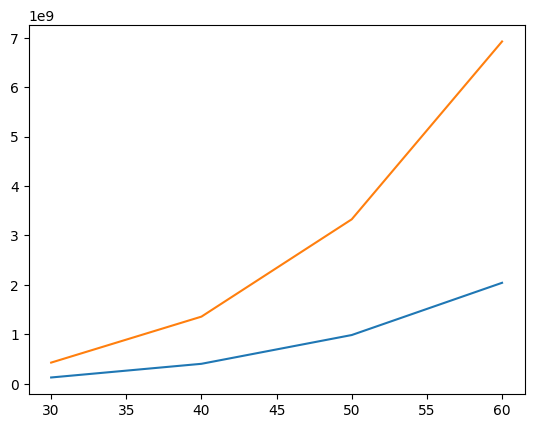

In [21]:
prefix = "power_flux_timeseries_r180"
files = sorted(output_dir.glob(f"{prefix}_*.csv"))
flux_outer_core = get_flux_grid(files,time_max_s, prefix)

flux_grid_outer_core = np.full((radius_values.size, wind_values.size), np.nan)

for (wind, radius), flux in flux_outer_core.items():
    flux_grid_outer_core[radius_index[radius], wind_index[wind]] = flux
plt.plot(wind_values,flux_grid_outer_core[0,:])
plt.plot(wind_values,flux_grid_outer_core[7,:])